<a href="https://colab.research.google.com/github/FajarWahyuSuryaputra/2025_pengolahan_citra_TI2B/blob/main/segmentasiGambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Praktikum 1
## Segmentasi Menggunakan Thresholding Global dan Otsu

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

In [ ]:
image_coins = data.coins()

In [ ]:
thresh_manual = 100
binary_manual = image_coins > thresh_manual

In [ ]:
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

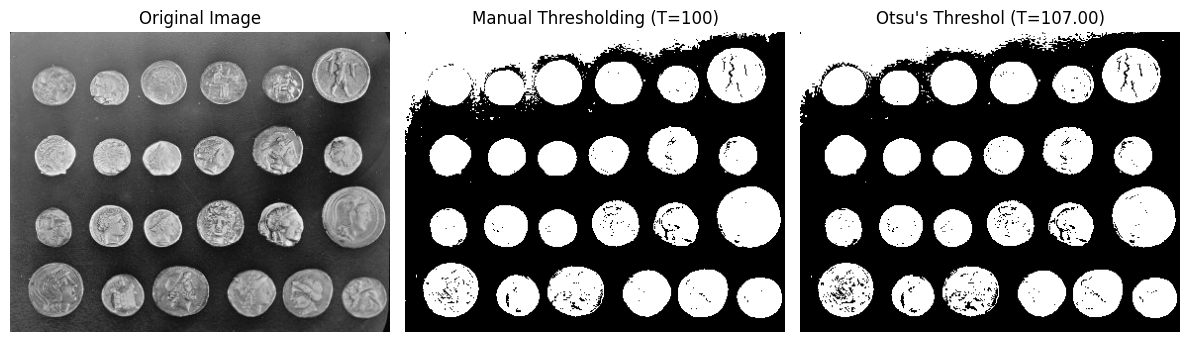

Nilai threshold Otsu yang ditemukan: 107


In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Thresholding (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s Threshol (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

### Praktikum 2
## Segmentasi Menggunakan Region Growing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

In [ ]:
image_camera = data.camera()

In [ ]:
seed_point = (50, 150)

In [ ]:
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

In [ ]:
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255

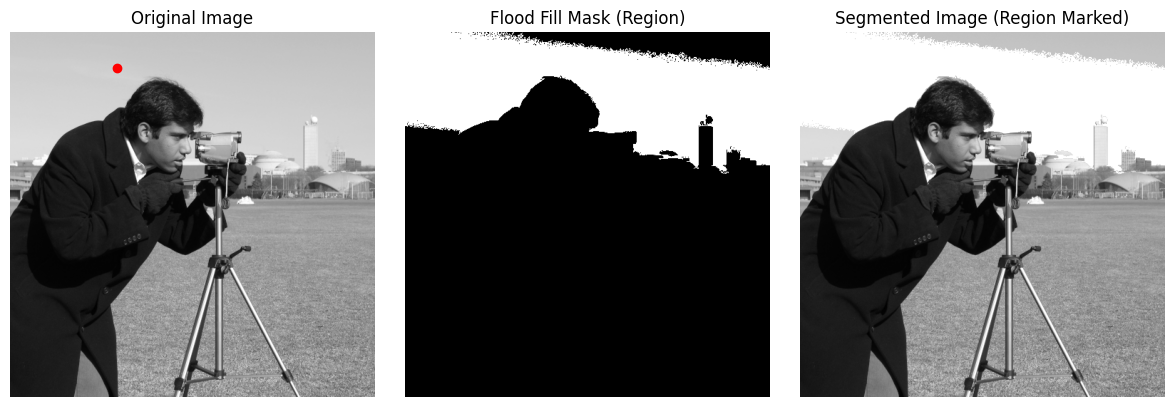

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### praktikum 3
## Segmentasi Citra Menggunakan K-Means Clustering

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

In [ ]:
image_astro = data.astronaut()
image_astro_float = image_astro.astype(float) / 255.0

In [ ]:
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

In [ ]:
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

In [ ]:
segmented_labels = pixel_labels.reshape(rows, cols)

In [ ]:
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
  cluster_pixels = (pixel_labels == k)
  mask_k = cluster_pixels.reshape(rows, cols)
  segmented_image_kmeans[mask_k] = centers_lab[k]

In [ ]:
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

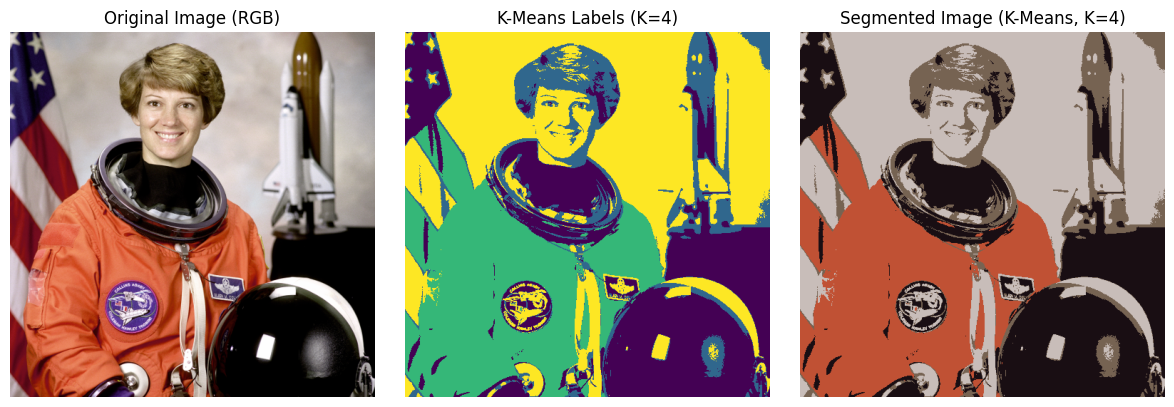

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

###praktikum 4
## Segmentasi Berbasis Tepi Menggunakan Watershed

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

In [ ]:
image_coins = data.coins()

elevation_map = filters.sobel(image_coins)

In [ ]:
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1
markers[image_coins > 150] = 2

In [ ]:
segmentation_watershed = segmentation.watershed(elevation_map, markers)

segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

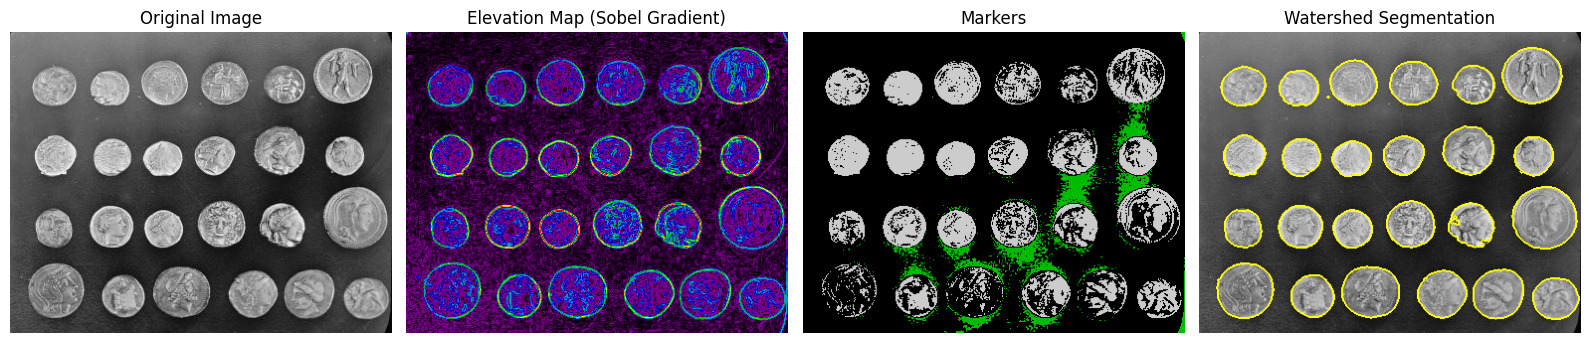

In [ ]:
fig, axes = plt.subplots(ncols=4, figsize=(16, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

### Praktikum 5
## Perbandingan Visual Hasil Segmentasi

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

In [ ]:
image = data.camera()
image_float = img_as_float(image)

In [ ]:
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

In [ ]:
rows, cols = image.shape
pixel_features = image.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

In [ ]:
elevation_map = filters.sobel(image)

markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2

segmentation_watershed = segmentation.watershed(elevation_map, markers)

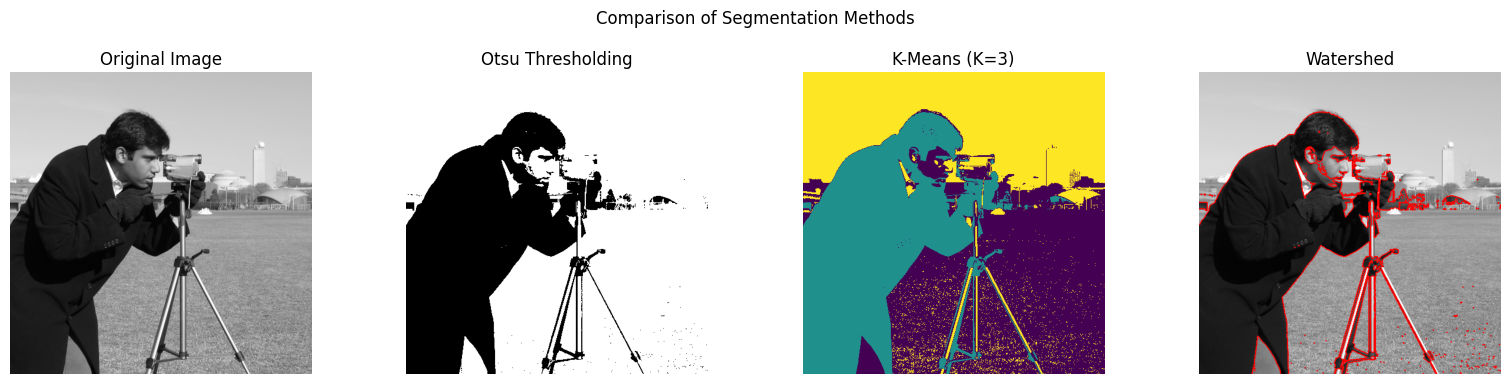

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

segmentation_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1, 0, 0))
ax[3].imshow(segmentation_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Tugas 1

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

In [ ]:
image_page = data.page()

In [ ]:
thresh_otsu = filters.threshold_otsu(image_page)
binary_otsu = image_page > thresh_otsu

In [ ]:
thresh_local = filters.threshold_local(image_page)
binary_local = image_page > thresh_local

In [ ]:
thresh_yen = filters.threshold_yen(image_page)
binary_yen = image_page > thresh_yen

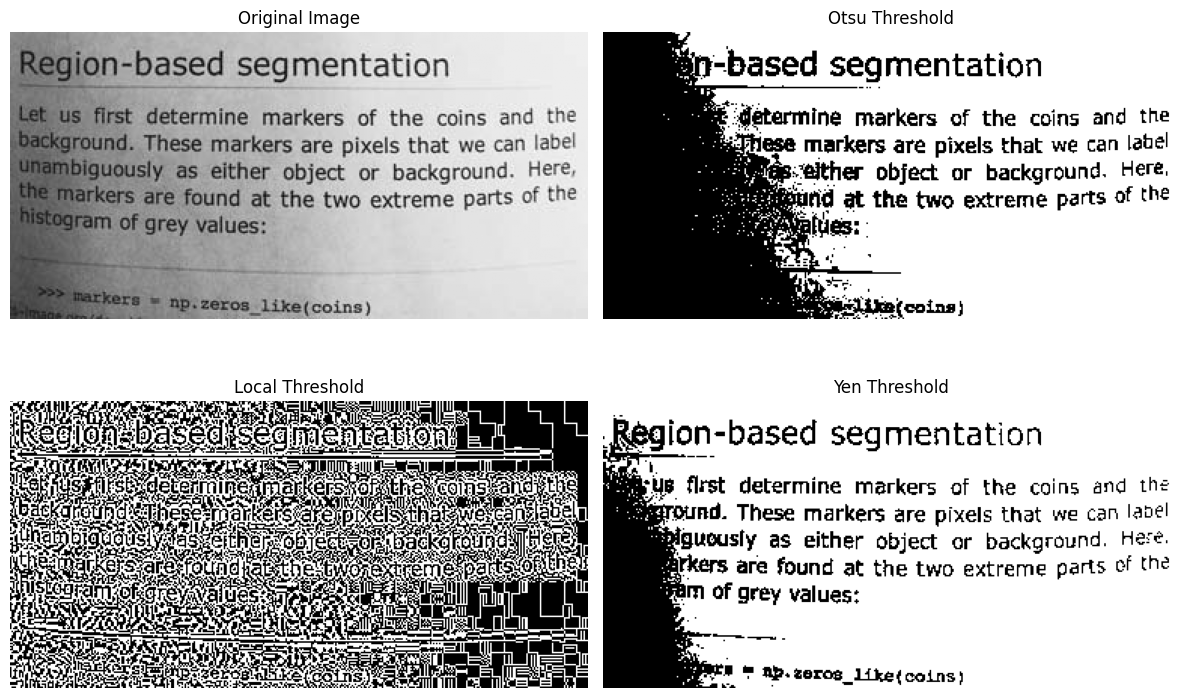

Nilai threshold Otsu yang ditemukan: 157


In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].imshow(image_page, cmap=plt.cm.gray)
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')

ax[0, 1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[0, 1].set_title('Otsu Threshold')
ax[0, 1].axis('off')

ax[1, 0].imshow(binary_local, cmap=plt.cm.gray)
ax[1, 0].set_title('Local Threshold')
ax[1, 0].axis('off')

ax[1, 1].imshow(binary_yen, cmap=plt.cm.gray)
ax[1, 1].set_title('Yen Threshold')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

###Tugas 2

In [4]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color, io
from sklearn.cluster import KMeans
import numpy as np
import warnings

In [8]:
foto_buah = io.imread('fotoBuah.jpg')
image = color.rgb2gray(foto_buah)
image_float = img_as_float(image)

In [9]:
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

In [15]:
rows, cols = image.shape
pixel_features = image.reshape(rows * cols, 1)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

In [13]:
elevation_map = filters.sobel(image)

markers = np.zeros_like(image, dtype=np.int32)
markers[image <= thresh_otsu] = 1
markers[image > thresh_otsu] = 2

segmentation_watershed = segmentation.watershed(elevation_map, markers)

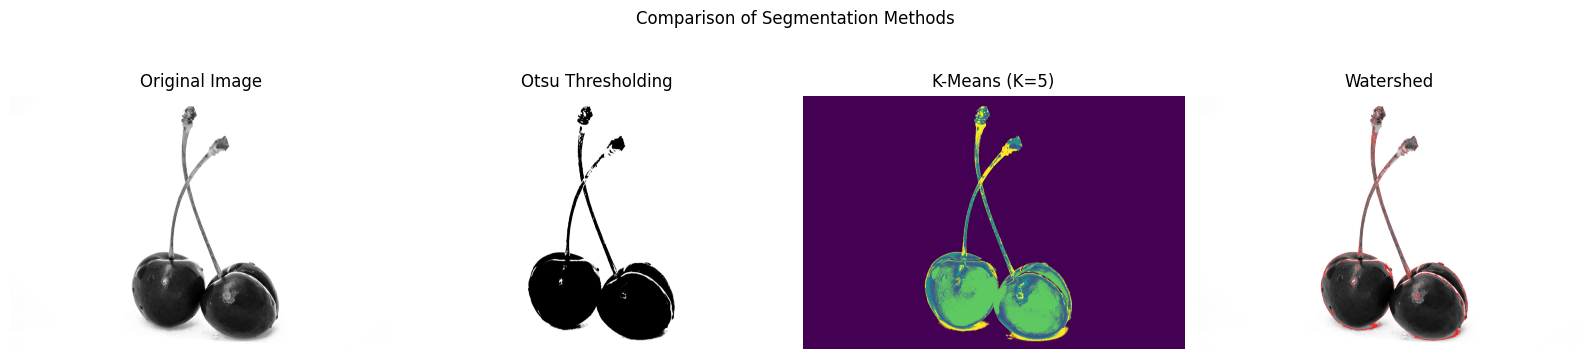

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

segmentation_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1, 0, 0))
ax[3].imshow(segmentation_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()